# 零基础实战机器学习

## 第18讲 增长模型裂变实战

作者 黄佳

极客时间专栏链接：https://time.geekbang.org/column/intro/438


问题：判断哪种裂变带来更大的增长幅度

营销团队为易速鲜花的用户设计了两种裂变方案——“情侣花享”和“拼团盛放”，一个是类似于买一送一的促销，让用户把促销分享给自己的另一半。另一个裂变方案是用过生成专属海报进行拼团购买，团越大促销折扣越大。

那么，如何让机器自动的识别出，某一种裂变（或者说其它促销方案）所最易感的人群，然后把该裂变发给他或她呢？


## 数据导入

In [1]:
import pandas as pd #导入Pandas
import numpy as np #导入NumPy
df_fission = pd.read_csv('易速鲜花增长模型.csv') #载入数据
print('用户数:', df_fission.count()['用户码']) #查看数据条目数
df_fission.head() #显示头几行数据

用户数: 64000


,用户码,曾助力,曾拼团,曾推荐,设备,城市类型,R值,M值,裂变类型,是否转化
0,1,0,1,0,电脑,中小,10,138.00,情侣花享,0
1,2,0,1,0,电脑,一线,4,105.59,拼团盛放,0
2,3,0,1,0,电脑,一线,1,494.13,拼团盛放,1
3,4,0,1,1,手机,二线,10,148.45,没有促销,0
4,5,1,0,0,手机,二线,2,337.18,拼团盛放,0


## 可视化

C:\Users\rossliao\AppData\Local\Temp\ipykernel_1716\3996061023.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(),rotation=25) #X轴标签倾斜


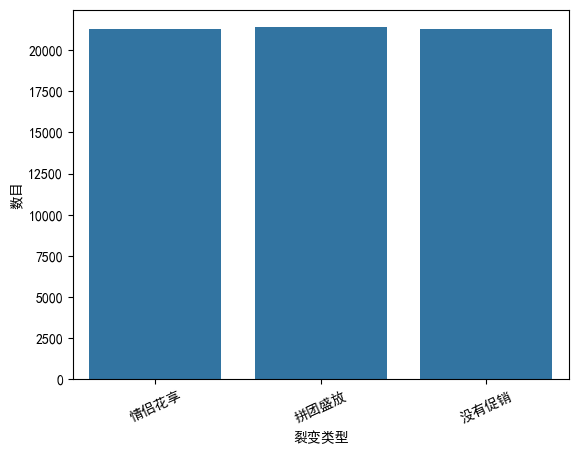

In [5]:
import matplotlib.pyplot as plt #导入pyplot模块
import seaborn as sns #导入Seaborn
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统常用字体
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统常用字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
fig = sns.countplot(x='裂变类型', data=df_fission) #创建柱状计数图
fig.set_xticklabels(fig.get_xticklabels(),rotation=25) #X轴标签倾斜
fig.set_ylabel("数目") #Y轴标题
plt.show() #显示图像

<BarContainer object of 3 artists>

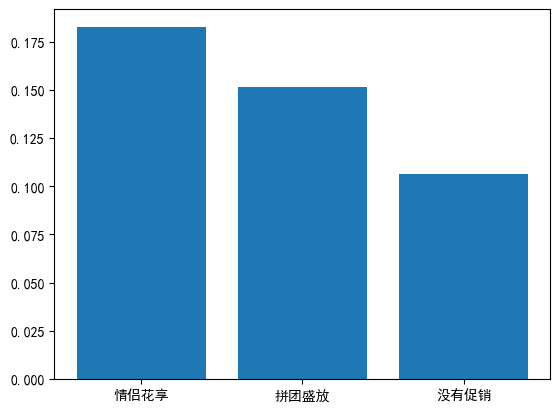

In [6]:
df_plot = df_fission.groupby('裂变类型').是否转化.mean().reset_index() #促销分组的转化率均值
plt.bar(df_plot['裂变类型'],df_plot['是否转化']) #不同促销转化均值柱状图

## 创建哑变量

In [7]:
df_dummies = df_fission.drop(['裂变类型'],axis=1) #在拆分哑变量前，先拿掉裂变类型
df_dummies = pd.get_dummies(df_dummies, drop_first = True) #为分类变量拆分哑变量
df_dummies['裂变类型'] = df_fission['裂变类型'] #把裂变类型放回去
df_fission = df_dummies.copy() #把哑变量数据集复制给元数据集
df_fission.head() #显示数据

,用户码,曾助力,曾拼团,曾推荐,R值,M值,是否转化,设备_手机,设备_电脑,城市类型_中小,城市类型_二线,裂变类型
0,1,0,1,0,10,138.00,0,False,True,True,False,情侣花享
1,2,0,1,0,4,105.59,0,False,True,False,False,拼团盛放
2,3,0,1,0,1,494.13,1,False,True,False,False,拼团盛放
3,4,0,1,1,10,148.45,0,True,False,False,True,没有促销
4,5,1,0,0,2,337.18,0,True,False,False,True,拼团盛放


### 构建特征和标签数据集

In [8]:
df_discount = df_fission.query("裂变类型 == '情侣花享' | 裂变类型 == '没有促销'")

In [9]:
df_discount.loc[(df_discount.裂变类型 == '情侣花享') & (df_discount.是否转化 == 1), '标签'] = 0 #有应答裂变组,裂变购买者
df_discount.loc[(df_discount.裂变类型 == '情侣花享') & (df_discount.是否转化 == 0), '标签'] = 1 #无应答裂变组,裂变未购买者
df_discount.loc[(df_discount.裂变类型 == '没有促销') &  (df_discount.是否转化 == 1), '标签'] = 2 #有应答控制组,无裂变购买者
df_discount.loc[(df_discount.裂变类型 == '没有促销') &  (df_discount.是否转化 == 0), '标签'] = 3 #无应答控制组,无裂变未购买者
df_discount.head()

C:\Users\rossliao\AppData\Local\Temp\ipykernel_1716\675391188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discount.loc[(df_discount.裂变类型 == '情侣花享') & (df_discount.是否转化 == 1), '标签'] = 0 #有应答裂变组,裂变购买者


,用户码,曾助力,曾拼团,曾推荐,R值,M值,是否转化,设备_手机,设备_电脑,城市类型_中小,城市类型_二线,裂变类型,标签
0,1,0,1,0,10,138.00,0,False,True,True,False,情侣花享,1.0
3,4,0,1,1,10,148.45,0,True,False,False,True,没有促销,3.0
5,6,0,1,1,10,56.48,0,False,True,False,True,情侣花享,1.0
6,7,1,1,1,2,551.98,0,False,False,False,False,情侣花享,1.0
8,9,1,0,1,7,29.99,1,False,True,False,True,情侣花享,0.0


In [10]:
X = df_discount.drop(['标签','是否转化'],axis=1) #特征集，Drop掉便签相关字段
y = df_discount.标签 #标签集

### 拆分数据集

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

In [12]:
X

,用户码,曾助力,曾拼团,曾推荐,R值,M值,设备_手机,设备_电脑,城市类型_中小,城市类型_二线,裂变类型
0,1,0,1,0,10,138.00,False,True,True,False,情侣花享
3,4,0,1,1,10,148.45,True,False,False,True,没有促销
5,6,0,1,1,10,56.48,False,True,False,True,情侣花享
6,7,1,1,1,2,551.98,False,False,False,False,情侣花享
8,9,1,0,1,7,29.99,False,True,False,True,情侣花享
...,...,...,...,...,...,...,...,...,...,...,...
63991,63992,1,0,1,2,509.72,True,False,False,True,情侣花享
63992,63993,1,0,0,1,29.99,True,False,True,False,情侣花享
63993,63994,0,1,1,2,499.62,True,False,True,False,情侣花享
63996,63997,0,1,1,3,158.03,True,False,False,True,情侣花享


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [14]:
import xgboost as xgb #导入xgboost模型
xgb_model = xgb.XGBClassifier() #创建xgboost模型
xgb_model.fit(X_train.drop(['用户码','裂变类型'], axis=1), y_train) #拟合xgboost模型

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
uplift_probs = xgb_model.predict_proba(X_test.drop(['用户码','裂变类型'], axis=1)) #预测测试集用户的分类概率
uplift_probs #显示4种概率

array([[0.08705848, 0.45078918, 0.04108788, 0.4210645 ],
       [0.02909767, 0.7355017 , 0.02701136, 0.20838925],
       [0.00945648, 0.70246154, 0.01172566, 0.27635634],
       ...,
       [0.05556571, 0.50935096, 0.05821663, 0.37686667],
       [0.20822178, 0.35344374, 0.04210222, 0.39623222],
       [0.09385349, 0.4288197 , 0.04099448, 0.43633235]],
      shape=(8523, 4), dtype=float32)

## 求出增量分数

In [20]:
discount_uplift = X_test.copy() #构建增量分数数据集   
discount_uplift['P_TR'] = uplift_probs[:,0] #添加有应答裂变概率
discount_uplift['P_TN'] = uplift_probs[:,1] #添加无应答裂变概率
discount_uplift['P_CR'] = uplift_probs[:,2] #添加有应答控制概率
discount_uplift['P_CN'] = uplift_probs[:,3] #添加无应答控制概率
#计算增量分数
discount_uplift['增量分数'] = discount_uplift.eval('P_TR + P_CN - (P_TN + P_CR)') 
# discount_uplift['增量分数'] = discount_uplift.eval('P_CN/(P_CN+P_CR) + P_TR/(P_TN+P_TR) - (P_TN/(P_TN+P_TR) - P_CR/(P_CN+P_CR))') 
discount_uplift

,用户码,曾助力,曾拼团,曾推荐,R值,M值,设备_手机,设备_电脑,城市类型_中小,城市类型_二线,裂变类型,P_TR,P_TN,P_CR,P_CN,增量分数
46726,46727,1,0,1,2,33.98,True,False,False,True,没有促销,0.087058,0.450789,0.041088,0.421064,0.016246
41918,41919,1,0,0,12,164.19,True,False,False,True,没有促销,0.029098,0.735502,0.027011,0.208389,-0.525026
20224,20225,1,0,1,12,365.07,False,False,False,False,没有促销,0.009456,0.702462,0.011726,0.276356,-0.428374
61417,61418,0,1,0,3,289.30,True,False,False,True,没有促销,0.044324,0.485111,0.091731,0.378833,-0.153685
15890,15891,1,0,1,4,29.99,True,False,False,True,没有促销,0.029167,0.418214,0.037603,0.515016,0.088366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17514,17515,1,1,1,11,721.57,True,False,False,False,情侣花享,0.013332,0.131662,0.004793,0.850213,0.727090
23281,23282,0,1,1,10,379.66,True,False,False,True,情侣花享,0.035995,0.526122,0.023625,0.414257,-0.099495
23524,23525,1,0,0,2,462.38,True,False,False,False,情侣花享,0.055566,0.509351,0.058217,0.376867,-0.135135
31173,31174,1,0,0,3,66.09,True,False,False,True,没有促销,0.208222,0.353444,0.042102,0.396232,0.208908
